In [1]:
# --- Figure 5 notebook header (build-from-source; no cache/pickles) ---
import sys
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt

here = Path.cwd()
for p in [here, *here.parents]:
    if (p / "utils.py").exists():
        sys.path.insert(0, str(p)); REPO = p; break
import utils
utils.frontiers_style()

# Build all processed data directly from the raw metalearning datasets (~15-20 min)
out = utils.process_all_tasks()

file_names   = list(out['out_agg'].keys())
problem_type = out['problem_type']
scores       = out['scores']
ia_os        = out['ia_os_merge']      # honest nested: select on INNER rank, score on OUTER test
out_agg      = out['out_agg']          # single-loop (kept for optional biased-vs-honest comparison)

basic_info = utils.load_basic_info()
clf, reg = utils.split_problem_lists(file_names, basic_info)
print(f"built: {len(file_names)} tasks | {len(clf)} clf | {len(reg)} reg | ia_os_merge for {len(ia_os)} tasks")

--- ext_qual_binary
--- ext_qual_failure_mode
--- ext_qual_filament_outcome
--- ext_quant_avg_force
--- ext_quant_avg_force_under4
--- ext_quant_curves
--- ext_quant_max_force
--- ext_quant_max_force_under5
--- ext_quant_stability
--- ext_quant_std_force
--- microgel_formation
--- microgel_init_size
--- microgel_jamming_curves
--- microgel_jamming_curves_over08
--- microgel_shape
--- microgel_size_evolution
--- microgel_size_evolution_under300
--- rheo_osc_plateau_loss
--- rheo_osc_plateau_loss_under20
--- rheo_osc_plateau_storage
--- rheo_osc_plateau_storage_over1000
--- rheo_osc_strain_loss_curves
--- rheo_osc_strain_storage_curves
--- rheo_osc_stress_loss_curves
--- rheo_osc_stress_storage_curves
--- rheo_osc_yield_strain
--- rheo_osc_yield_strain_over10
--- rheo_osc_yield_stress
--- rheo_osc_yield_stress_over20
--- rheo_rot_shear_curves
--- rheo_rot_yield
built: 31 tasks | 14 clf | 17 reg | ia_os_merge for 31 tasks


In [2]:
# ===================== F5 — frames + sanity (run before plotting) =====================
KEYS   = ['iteration', 'outer_k', 'outer_split', 'inner_k']    # one nested instance
M1     = {'clf': 'mean_accuracy', 'reg': 'mean_MAE'}           # INNER selection metric
OUT    = {'clf': 'outer_accuracy', 'reg': 'outer_MAE'}         # OUTER held-out score
BETTER = {'clf': 'high', 'reg': 'low'}
STRAT_ORDER = ['AS', 'HPO', 'CASH', 'AS_HPO']                  # HPO = naive blend; AS_HPO = principled

reward_rows, risk_rows, diag = [], [], []
for kind, tasks in [('clf', clf), ('reg', reg)]:
    yi, yo = M1[kind], OUT[kind]
    rc_as, rc_hpo, rc_cash = f'rank_as_{yi}', f'rank_hpo_{yi}', f'rank_cash_{yi}'
    av = [c for c in ia_os[tasks[0]].columns if c.startswith('outer_')]
    assert yo in ia_os[tasks[0]].columns, f"{kind}: outer col {yo} not found; available: {av}"
    for c in [yi, rc_as, rc_hpo, rc_cash, 'default_config', 'algorithm']:
        assert c in ia_os[tasks[0]].columns, f"{kind}: missing {c}"

    n_inst, n_drop, ties_as, ties_cash = 0, 0, 0, 0
    for t in tasks:
        df = ia_os[t]; n_inst += df.groupby(KEYS).ngroups
        # ---- winners (average OUTER over rank==1 ties) ----
        as_out   = df[df[rc_as]   == 1].groupby(KEYS)[yo].mean()
        cash_out = df[df[rc_cash] == 1].groupby(KEYS)[yo].mean()
        hpo_out  = df[df[rc_hpo]  == 1].groupby(KEYS + ['algorithm'])[yo].mean()   # per algorithm (blend)
        as_algos = df[df[rc_as] == 1][KEYS + ['algorithm']].drop_duplicates()      # AS-winning algo(s)
        ashpo_out = (df[df[rc_hpo] == 1].merge(as_algos, on=KEYS + ['algorithm'])
                       .groupby(KEYS)[yo].mean())                                   # tune the AS algo
        ties_as   += int(df[df[rc_as]   == 1].groupby(KEYS).size().gt(1).sum())
        ties_cash += int(df[df[rc_cash] == 1].groupby(KEYS).size().gt(1).sum())
        # ---- space means (OUTER) for risk panel ----
        as_mean    = df[df.default_config == 'default'].groupby(KEYS)[yo].mean()
        cash_mean  = df.groupby(KEYS)[yo].mean()
        hpo_mean   = df.groupby(KEYS + ['algorithm'])[yo].mean()
        ashpo_mean = df.merge(as_algos, on=KEYS + ['algorithm']).groupby(KEYS)[yo].mean()

        # ---- REWARD ratios: EVERY denominator is the AS winner (rank_as==1), never defaults ----
        ref = as_out.dropna(); n_drop += int(as_out.isna().sum())
        def push(rows, strat, series, denom, on_algo=False):
            if on_algo:
                x = series.reset_index().merge(denom.rename('den').reset_index(), on=KEYS)
                r = (x[yo] / x['den']).replace([np.inf, -np.inf], np.nan).dropna()
            else:
                r = (series / denom).replace([np.inf, -np.inf], np.nan).dropna()
            rows.append(pd.DataFrame({'task': t, 'kind': kind, 'strategy': strat, 'ratio': np.asarray(r)}))
        push(reward_rows, 'AS',     ref,       ref)
        push(reward_rows, 'CASH',   cash_out,  ref)
        push(reward_rows, 'AS_HPO', ashpo_out, ref)
        push(reward_rows, 'HPO',    hpo_out,   ref, on_algo=True)
        # ---- RISK ratios: winner ÷ its own space-mean ----
        push(risk_rows, 'AS',     as_out,    as_mean)
        push(risk_rows, 'CASH',   cash_out,  cash_mean)
        push(risk_rows, 'AS_HPO', ashpo_out, ashpo_mean)
        # HPO risk aligns on KEYS+algorithm
        hr = hpo_out.reset_index().merge(hpo_mean.rename('m').reset_index(), on=KEYS + ['algorithm'])
        hr = hr.assign(ratio=hr[yo] / hr['m']).replace([np.inf, -np.inf], np.nan).dropna(subset=['ratio'])
        risk_rows.append(pd.DataFrame({'task': t, 'kind': kind, 'strategy': 'HPO', 'ratio': hr['ratio'].values}))
    diag.append((kind, n_inst, n_drop, ties_as, ties_cash))

reward = pd.concat(reward_rows, ignore_index=True)
risk   = pd.concat(risk_rows,   ignore_index=True)
for D in (reward, risk): D['strategy'] = pd.Categorical(D['strategy'], STRAT_ORDER, ordered=True)

# ---- sanity ----
for kind, ni, nd, ta, tc in diag:
    print(f"[{kind}] instances={ni} | AS-ref NaN dropped={nd} | AS ties={ta} | CASH ties={tc}")
for kind in ['clf', 'reg']:
    print(f"  {kind} OUTER median ({OUT[kind]}): "
          f"{np.nanmedian(np.concatenate([ia_os[t][OUT[kind]].dropna().values for t in (clf if kind=='clf' else reg)])):.3f}")
print("\nREWARD ratio ÷ AS winner  (clf >1 = beats AS ; reg <1 = beats AS):")
print(reward.groupby(['kind','strategy'], observed=True)['ratio'].agg(['median','mean','count']).round(4))
print("\nRISK ratio = winner ÷ space-mean  (distance from 1 = stakes of selection; CASH should be most extreme):")
print(risk.groupby(['kind','strategy'], observed=True)['ratio'].agg(['median','mean']).round(4))
assert np.allclose(reward.loc[reward.strategy=='AS','ratio'], 1.0), "AS reward must be exactly 1.0"
print("\nGUARD OK: reward denominator = AS winner (rank_as==1) OUTER score, not default_config mean; AS/AS==1.0.")

[clf] instances=5040 | AS-ref NaN dropped=0 | AS ties=1651 | CASH ties=3505
[reg] instances=6120 | AS-ref NaN dropped=12 | AS ties=0 | CASH ties=530
  clf OUTER median (outer_accuracy): 0.814
  reg OUTER median (outer_MAE): 54.339

REWARD ratio ÷ AS winner  (clf >1 = beats AS ; reg <1 = beats AS):
               median    mean  count
kind strategy                       
clf  AS        1.0000  1.0000   5040
     HPO       1.0000  0.9787  35280
     CASH      1.0000  0.9961   5040
     AS_HPO    1.0000  0.9981   5040
reg  AS        1.0000  1.0000   6108
     HPO       1.0687  1.5491  42705
     CASH      0.9723  1.0577   6099
     AS_HPO    0.9900  0.9615   6108

RISK ratio = winner ÷ space-mean  (distance from 1 = stakes of selection; CASH should be most extreme):
               median    mean
kind strategy                
clf  AS        1.0667  1.0769
     HPO       1.0526  1.0824
     CASH      1.0862  1.0924
     AS_HPO    1.0479  1.0609
reg  AS        0.4643  0.5053
     HPO       0

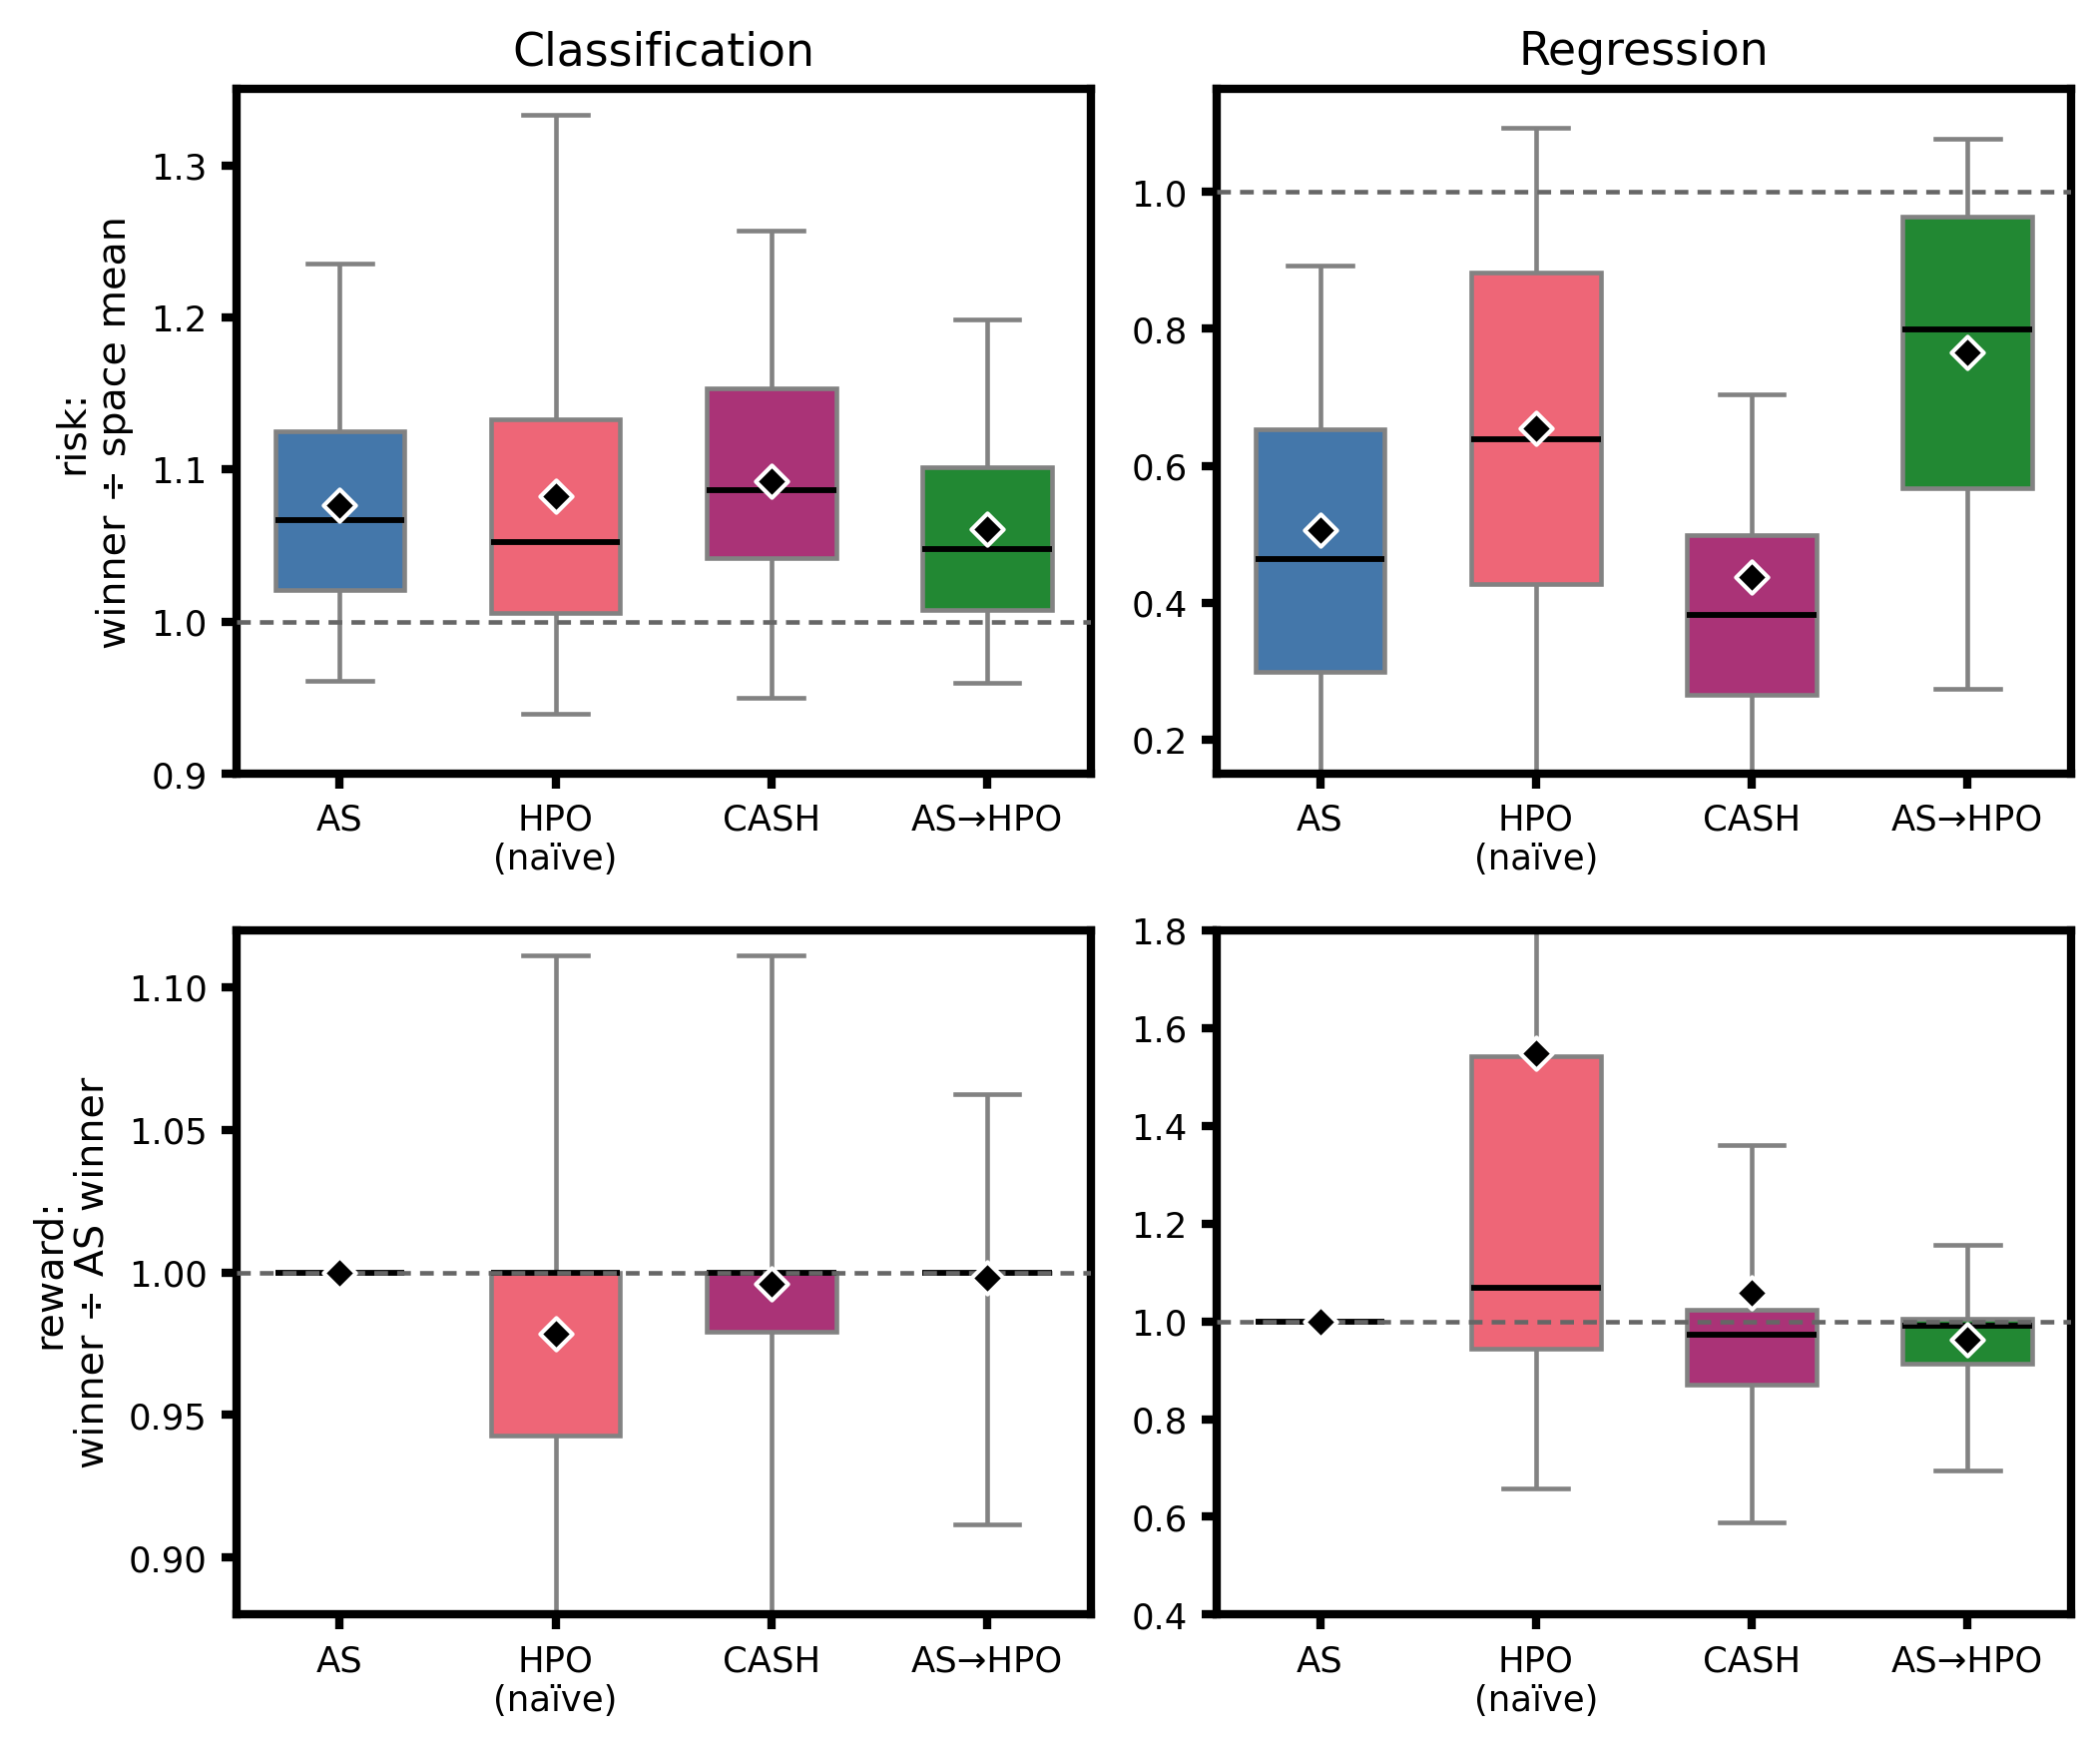

In [3]:
# ===================== F5 — figure (2x2: reward / risk  ×  clf / reg) =====================
import seaborn as sns
plt.rcParams.update({
    'axes.linewidth': 2.0, 'font.size': 9, 'axes.titlesize': 11, 'axes.labelsize': 9.5,
    'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5, 'xtick.major.width': 2.0, 'ytick.major.width': 2.0,
    'pdf.fonttype': 42, 'ps.fonttype': 42,
})
STRAT_PAL = {'AS':'#4477AA', 'HPO':'#EE6677', 'CASH':'#AA3377', 'AS_HPO':'#228833'}
STRAT_LAB = {'AS':'AS', 'HPO':'HPO\n(naïve)', 'CASH':'CASH', 'AS_HPO':'AS→HPO'}
PANELS = [('risk',   risk,   'risk:\nwinner ÷ space mean'),
          ('reward', reward, 'reward:\nwinner ÷ AS winner')]
YLIM = {('reward','clf'):(0.88,1.12), ('reward','reg'):(0.4,1.8),
        ('risk','clf'):(0.90,1.35),  ('risk','reg'):(0.15,1.15)}

fig, axes = plt.subplots(2, 2, figsize=(180/25.4, 150/25.4))
for ri, (panel, D, ylab) in enumerate(PANELS):
    for ci, kind in enumerate(['clf', 'reg']):
        ax = axes[ri, ci]
        d = D[D.kind == kind]
        sns.boxplot(data=d, x='strategy', y='ratio', order=STRAT_ORDER, ax=ax,
                    whis=(5,95), showfliers=False, width=0.6, color='0.85',
                    linewidth=1.1, medianprops=dict(color='black', lw=1.4))
        for p, s in zip(ax.patches, STRAT_ORDER): p.set_facecolor(STRAT_PAL[s])
        means = d.groupby('strategy', observed=True)['ratio'].mean().reindex(STRAT_ORDER)
        ax.scatter(range(4), means.values, marker='D', s=30, color='black',
                   edgecolor='white', lw=1.0, zorder=10)
        ax.axhline(1.0, color='0.4', lw=1.1, ls=(0,(3,2)), zorder=3)   # AS reference
        ax.set_ylim(*YLIM[(panel, kind)])
        ax.set_xticks(range(4)); ax.set_xticklabels([STRAT_LAB[s] for s in STRAT_ORDER])
        ax.set_xlabel('')
        if ri == 0: ax.set_title('Classification' if kind=='clf' else 'Regression', fontsize=11, pad=6)
        ax.set_ylabel(ylab if ci == 0 else '')
        # annotate any mean that falls outside the clip (so the skew isn't hidden)
        for i, s in enumerate(STRAT_ORDER):
            mv = means[s]
            if mv > YLIM[(panel,kind)][1]:
                ax.annotate(f'mean {mv:.2f}', xy=(i, YLIM[(panel,kind)][1]), ha='center', va='top',
                            fontsize=6.5, color='black')
fig.tight_layout()

In [5]:
from pathlib import Path
figdir = REPO / "figures"; figdir.mkdir(exist_ok=True)
fig.savefig(figdir / "Figure5_search.pdf", dpi=300, bbox_inches='tight')
fig.savefig(figdir / "Figure5_search.png", dpi=300, bbox_inches='tight')  # for quick viewing
print("saved to", figdir)

saved to C:\Users\conno\Documents\GitHub\ML_MetaLearning_SoftMatter\figures
